# Week 1: Foundations & the Forecaster's Toolbox
## In-Class Exercises

**Objective.** Load a series, see its patterns, fit the four benchmark methods, and judge them honestly with out-of-sample error and residual diagnostics.

### How this notebook works

Three parts, each building on the one before it.

| Part | Format | Content |
| --- | --- | --- |
| 1 | Walkthrough | Time plot, seasonal plot, ACF, and four series where I know the answer. |
| 2 | Blanks we fill in together | The four benchmarks, scored on a holdout, then residual diagnostics. |
| 3 | On your own, ~10 min | The same pipeline on a different series. Solutions included. |

In [1]:
!pip install -q pandas numpy plotly matplotlib statsmodels

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

pio.templates.default = "plotly_white"   # try "plotly_dark", "ggplot2", "simple_white"

# Series and forecasts are plotly, so they are easy to restyle. Correlograms stay
# with statsmodels' plot_acf, which draws the confidence band for you.

URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
air = pd.read_csv(URL, parse_dates=["Month"], index_col="Month")["Passengers"]
air = air.asfreq("MS")
air.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [3]:
# Error metrics we will use all term. Keep this cell handy.

def mae(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return np.mean(np.abs(y - yhat))

def rmse(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return np.sqrt(np.mean((y - yhat) ** 2))

def mape(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return 100 * np.mean(np.abs((y - yhat) / y))

def mase(y, yhat, y_train, m=1):
    """Scaled error. Denominator is the in-sample seasonal-naive MAE."""
    y_train = np.asarray(y_train, float)
    scale = np.mean(np.abs(y_train[m:] - y_train[:-m]))
    return mae(y, yhat) / scale

def score(y, yhat, y_train, m=12):
    return {"MAE": mae(y, yhat), "RMSE": rmse(y, yhat),
            "MAPE": mape(y, yhat), "MASE": mase(y, yhat, y_train, m)}

---
## Part 1. Seeing the patterns

Three plots do most of the diagnostic work: the time plot, the seasonal plot, and the ACF.

Watch for two things. Which of **trend**, **seasonality**, and **cyclic** behavior is present, and whether the seasonal swing grows with the level. The second decides additive vs. multiplicative later.

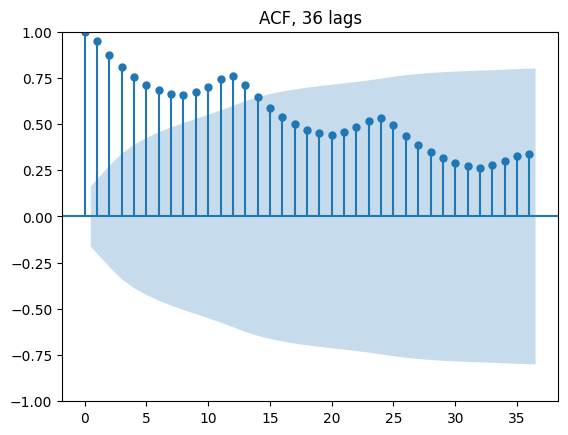

In [4]:
# (a) Time plot
px.line(air.reset_index(), x="Month", y="Passengers",
        title="Airline passengers, monthly",
        labels={"Passengers": "thousands"}).show()

# (b) Seasonal plot: one line per year, months on the x-axis
seasonal = (air.reset_index()
              .assign(year=lambda d: d["Month"].dt.year.astype(str),
                      month=lambda d: d["Month"].dt.month))
px.line(seasonal, x="month", y="Passengers", color="year", markers=True,
        title="Seasonal plot: one line per year").show()

# (c) ACF
plot_acf(air, lags=36, title="ACF, 36 lags")
plt.show()

**Notice:**

1. Clear upward trend and a repeating annual shape.
2. The seasonal plot stacks the years. The summer peak lands in the same month every year and grows over time. That is *multiplicative* seasonality.
3. The ACF decays slowly (trend) and bumps at lag 12 (seasonality). It never enters the confidence band, so this is not white noise.

Now four synthetic series where I know the answer.

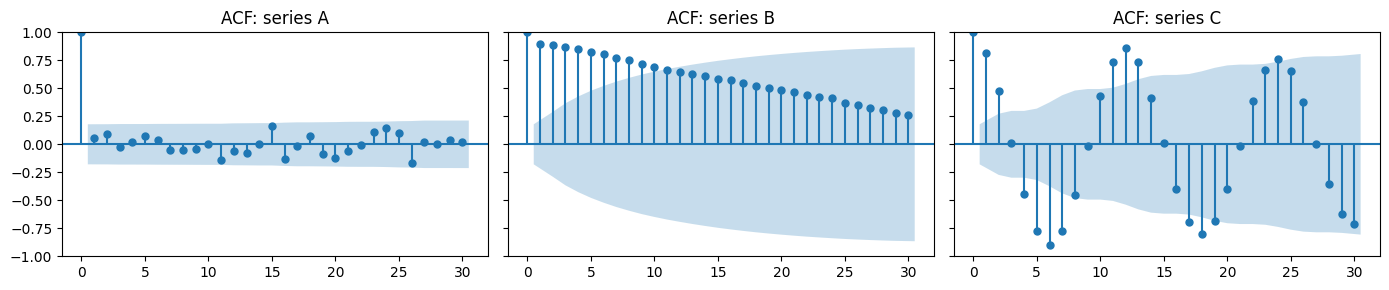

In [8]:
rng = np.random.default_rng(0)
n = 120
t = np.arange(n)
examples = pd.DataFrame({
    "A": rng.normal(size=n),
    "B": 0.05 * t + rng.normal(scale=0.5, size=n),
    "C": 3 * np.sin(2 * np.pi * t / 12) + rng.normal(scale=0.5, size=n),
    #"D": np.cumsum(rng.normal(size=n)),
})

tidy = examples.rename_axis("t").reset_index().melt(id_vars="t", var_name="series", value_name="value")
fig = px.line(tidy, x="t", y="value", facet_col="series", height=300, title="Four series")
fig.update_yaxes(matches=None)
fig.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=True)
for ax, c in zip(axes, examples):
    plot_acf(examples[c], lags=30, ax=ax, title=f"ACF: series {c}")
plt.tight_layout()
plt.show()

**For discussion:** label each series as white noise, trend, seasonal, or random walk, and name the ACF feature that gave it away.

---
## Part 2. The four benchmarks

The baselines every later model has to beat. Fill in the `TODO`s with me.

On a test set of length `h`:

- **Mean**: the average of the training data, repeated.
- **Naive**: the last training observation, repeated.
- **Seasonal naive**: the value from the same season in the last full cycle.
- **Drift**: the last value plus the average historical slope, extrapolated.

In [9]:
h = 24
train, test = air[:-h], air[-h:]
m = 12  # seasonal period

print(f"train: {train.index.min():%Y-%m} to {train.index.max():%Y-%m}  ({len(train)} obs)")
print(f"test : {test.index.min():%Y-%m} to {test.index.max():%Y-%m}  ({len(test)} obs)")

train: 1949-01 to 1958-12  (120 obs)
test : 1959-01 to 1960-12  (24 obs)


In [21]:
fc = pd.DataFrame(index=test.index)

# Mean method
fc["Mean"] = train.mean()

# Naive method: last observation carried forward
fc["Naive"] = train.iloc[-1]

# Seasonal naive: TODO - take the last `m` observations of train and tile them.
fc["SeasonalNaive"] = np.tile(train.iloc[-m:].to_numpy(), int(np.ceil(h / m)))[:h]
#   Hint: np.tile(train.iloc[-1].iloc[-m:].to_numpy(), int(np.ceil(h / m)))[:h]

# Drift: last value + slope * steps ahead, where
#   slope = (last - first) / (len(train) - 1)
# TODO - write the drift forecast
slope = (train.iloc[-1]-train.iloc[1])/(len(train)-1)
fc["Drift"] = train.iloc[-1] + slope * np.arange(1, h + 1)

fc["SeasonalNaive_Drift"] = fc["SeasonalNaive"] + fc["Drift"]-train.iloc[-1]

fc.head()

,Mean,Naive,SeasonalNaive,Drift,SeasonalNaive_Drift
Month,,,,,
1959-01-01,245.908333,337,340,338.840336,341.840336
1959-02-01,245.908333,337,318,340.680672,321.680672
1959-03-01,245.908333,337,362,342.521008,367.521008
1959-04-01,245.908333,337,348,344.361345,355.361345
1959-05-01,245.908333,337,363,346.201681,372.201681


<details>
<summary><b>Show the two filled-in lines</b></summary>

```python
fc["SeasonalNaive"] = np.tile(train.iloc[-m:].to_numpy(), int(np.ceil(h / m)))[:h]

slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
fc["Drift"] = train.iloc[-1] + slope * np.arange(1, h + 1)
```
</details>

In [22]:
plot_df = pd.concat([
    train[-48:].rename("value").to_frame().assign(series="train"),
    test.rename("value").to_frame().assign(series="test"),
    fc.melt(ignore_index=False, var_name="series", value_name="value"),
]).rename_axis("date").reset_index()

px.line(plot_df, x="date", y="value", color="series",
        title="Four benchmarks vs. the held-out truth").show()

In [23]:
results = pd.DataFrame({name: score(test, fc[name], train, m) for name in fc}).T
results.round(2).sort_values("MASE")

,MAE,RMSE,MAPE,MASE
SeasonalNaive_Drift,48.25,52.01,10.49,1.69
SeasonalNaive,71.25,76.99,15.52,2.49
Drift,92.25,116.25,18.55,3.23
Naive,115.25,137.33,23.58,4.03
Mean,206.34,219.44,44.23,7.22


**Reading the table.**

- Seasonal naive should win. It is the only benchmark that knows the series repeats every 12 months.
- Its MASE lands near 1 by construction: MASE is scaled by the *in-sample* one-step seasonal-naive error.
- MAPE and RMSE do not always rank the methods the same way. Pick your metric before you see results, not after.

Now the winner's residuals. A good model leaves behind noise and nothing else.

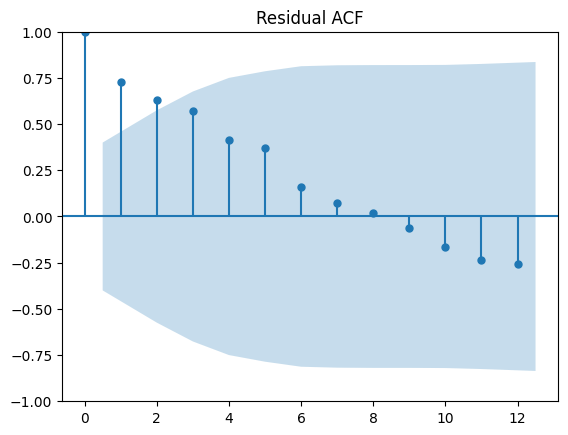

mean residual: 71.25   (want ~0)
     lb_stat     lb_pvalue
12  53.77828  2.993405e-07

Ljung-Box p > 0.05 => cannot reject white noise => little signal left on the table.


In [19]:
best = results["MASE"].idxmin()
resid = (test - fc[best]).rename("residual")

fig = px.line(resid.rename_axis("date").reset_index(), x="date", y="residual", markers=True,
              title=f"{best} residuals over time", height=320)
fig.add_hline(y=0, line_color="crimson")
fig.show()

plot_acf(resid, lags=12, title="Residual ACF")
plt.show()

px.histogram(resid, nbins=12, title="Residual histogram", height=320).show()

lb = acorr_ljungbox(resid, lags=[12], return_df=True)
print(f"mean residual: {resid.mean():.2f}   (want ~0)")
print(lb)
print("\nLjung-Box p > 0.05 => cannot reject white noise => little signal left on the table.")

---
## Part 3. The whole pipeline on a new series

About 10 minutes. The cell below loads **monthly atmospheric CO2** (Mauna Loa, from `statsmodels`): strong trend, mild annual cycle. Different shape, same workflow.

**Tasks.**

1. Plot the series and its ACF, and name the patterns present.
2. Hold out the last 24 observations.
3. Fit all four benchmarks and score them with `score(...)`.
4. Name the winner and explain whether the ranking matches the airline result.
5. Plot the winner's residuals and run Ljung-Box. Report whether signal is left.

Write (4) and (5) in a text cell.

In [24]:
import statsmodels.api as sm

co2 = sm.datasets.co2.load_pandas().data["co2"].resample("MS").mean().interpolate()
co2 = co2["1990":]      # a manageable slice
px.line(x=co2.index, y=co2.to_numpy(), title="Mauna Loa CO2, ppm",
        labels={"x": "date", "y": "ppm"}).show()
co2.tail()

,co2
2001-08-01,369.425
2001-09-01,367.880
2001-10-01,368.050
2001-11-01,369.375
2001-12-01,371.020


In [ ]:
# YOUR CODE HERE
# 1. plots
# 2. train / test split, h = 24
# 3. four benchmarks
# 4. score table
# 5. residual diagnostics on the winner

<details>
<summary><b>Solution</b></summary>

```python
h, m = 24, 12
tr, te = co2[:-h], co2[-h:]

f = pd.DataFrame(index=te.index)
f["Mean"] = tr.mean()
f["Naive"] = tr.iloc[-1]
f["SeasonalNaive"] = np.tile(tr.iloc[-m:].to_numpy(), int(np.ceil(h / m)))[:h]
slope = (tr.iloc[-1] - tr.iloc[0]) / (len(tr) - 1)
f["Drift"] = tr.iloc[-1] + slope * np.arange(1, h + 1)

print(pd.DataFrame({k: score(te, f[k], tr, m) for k in f}).T.round(3).sort_values("MASE"))

best = "Drift"
r = te - f[best]
plot_acf(r, lags=12, title=f"{best} residual ACF")
plt.show()
print(acorr_ljungbox(r, lags=[12], return_df=True))
```

**What you should find.** Drift usually beats seasonal naive here: the trend dominates and the seasonal swing is small next to it. That is the opposite of the airline result. The best benchmark is a property of the series, not a fact about forecasting.

The winner's residuals are also *not* white noise, because no single benchmark captures trend and seasonality at once. Weeks 2 and 3 fill that gap.
</details>

---
## Wrap-up

1. **Plot before you model.** The three plots in Part 1 determine most of what follows.
2. **The benchmark is the bar.** A model that cannot beat seasonal naive out of sample is not a model.
3. **A single split is one noisy draw.** Rolling-origin CV is the default once real decisions ride on it.

Next week: pulling trend and seasonality apart with STL.